In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from qiskit_ibm_runtime.fake_provider import FakeAuckland, FakeManilaV2
#from qiskit_ibm_runtime import SamplerV2 as Sampler

In [3]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit.circuit.library import RealAmplitudes
from qiskit.quantum_info import Operator, SparsePauliOp

In [4]:
x0 = 0
y0 = 0.2

step_size = 0.1

xn = 5

In [5]:
X = np.arange(x0, xn + step_size, step_size)


In [6]:
#z = np.log(np.abs(-y))
h = np.log(np.abs(step_size))

In [ ]:
#Real Hardware
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

backend = service.least_busy(operational=True, simulator=False)


In [7]:
#Fake Backend
backend = FakeManilaV2()

In [8]:
estimator = Estimator(backend)

In [9]:
qc = QuantumCircuit(1)

qc.h(0)

In [10]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_psi = pm.run(qc)


In [11]:
y_pred = [y0]
y = y0

for i in X[1:]:

    Y = y*(1 - y)
    z = np.log(np.abs(Y))

    h_m = np.array([[h, 0],
                    [0, z]])

    opm = Operator(h_m)
    h_m = SparsePauliOp.from_operator(opm)

    isa_observables1 = h_m.apply_layout(isa_psi.layout)
    job1 = estimator.run([(isa_psi, isa_observables1)], precision=0.001 )

    job_result1 = job1.result()[0] # It will block until the job finishes.
    expv1 = job_result1.data.evs
    m = np.exp(2*expv1) * np.sign(Y)
    #print(i, "m:", np.round(m, 2), ",", "Y:", np.round(Y, 2) )
    
    h_s = np.array([[y, 0],
                    [0, m]])

    ops = Operator(h_s)
    h_s = SparsePauliOp.from_operator(ops)

    isa_observables2 = h_s.apply_layout(isa_psi.layout)
    job2 = estimator.run([(isa_psi, isa_observables2)], precision=0.001)

    job_result2 = job2.result()[0] # It will block until the job finishes.
    expv2 = job_result2.data.evs
    ans = 2*expv2

    y = ans
    #print("y", np.round(y, 2))
    y_pred.append(y)
    


In [12]:
# initial condition
y_true = [y0]
y = y0

# Euler method
for i in X[1:]:
    Y = y*(1 - y)

    y = y + step_size * (Y)   # dy/dx = -y
    y_true.append(y)

# print results
# for x, y in zip(x_vals, y_vals):
#     print(f"x = {x}, y = {y}")

In [13]:
print(len(X), len(y_pred), len(y_true))

51 51 51


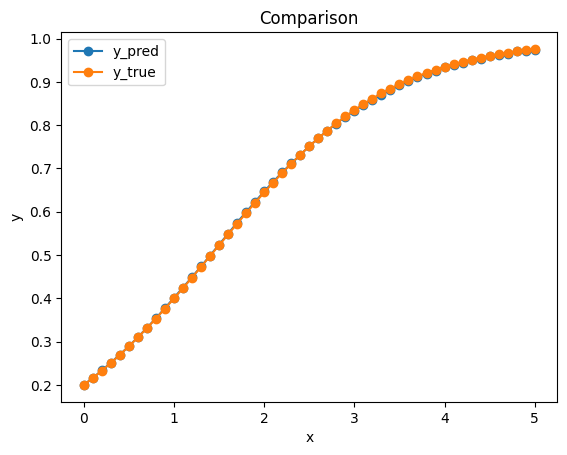

In [14]:
import matplotlib.pyplot as plt

plt.plot(X, y_pred, 'o-', label="y_pred")  # dots + line
plt.plot(X, y_true, 'o-', label="y_true")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparison")
plt.legend()

plt.show()

In [15]:
mse = sum((a - b)**2 for a, b in zip(y_pred, y_true)) / len(y_pred)
print(mse)

2.91122891793459e-06


In [16]:
import pandas as pd

df = pd.DataFrame({
    "x": X,
    "y_pred": y_pred,
    "y": y_true
})

print(df)

      x    y_pred         y
0   0.0  0.200000  0.200000
1   0.1  0.216362  0.216000
2   0.2  0.233381  0.232934
3   0.3  0.251376  0.250802
4   0.4  0.270070  0.269592
5   0.5  0.289593  0.289283
6   0.6  0.310297  0.309843
7   0.7  0.331898  0.331227
8   0.8  0.354065  0.353379
9   0.9  0.377569  0.376229
10  1.0  0.401268  0.399697
11  1.1  0.425029  0.423691
12  1.2  0.449016  0.448109
13  1.3  0.473733  0.472839
14  1.4  0.498851  0.497766
15  1.5  0.524123  0.522765
16  1.6  0.549128  0.547713
17  1.7  0.575116  0.572486
18  1.8  0.599462  0.596960
19  1.9  0.623248  0.621020
20  2.0  0.646857  0.644555
21  2.1  0.669234  0.667466
22  2.2  0.691154  0.689661
23  2.3  0.711497  0.711064
24  2.4  0.731268  0.731609
25  2.5  0.751662  0.751245
26  2.6  0.769856  0.769933
27  2.7  0.787378  0.787646
28  2.8  0.803776  0.804372
29  2.9  0.819633  0.820108
30  3.0  0.832787  0.834861
31  3.1  0.847125  0.848648
32  3.2  0.858640  0.861492
33  3.3  0.869730  0.873425
34  3.4  0.881457  0